# Risco de crédito: do CSV ao veredito

Este notebook percorre as seis Etapas do projeto. Execute as células em ordem, a partir da pasta do projeto. O processamento lê os CSVs originais, grava as saídas em `resultados/` e `dados_derivados/` e confere os arquivos de entrada por hash. O alvo positivo, `loan_status=1`, indica inadimplência.

Os textos abaixo explicam as decisões. A implementação está em `notebooks/pipeline_credito.py`; as funções indicadas em cada fase permitem conferir o processamento.


In [1]:
from pathlib import Path
import sys, os, runpy
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
assert (ROOT / 'credit_risk_dataset.csv').exists(), 'Abra o notebook na pasta do projeto.'
sys.path.insert(0, str(ROOT / 'notebooks'))
os.environ.setdefault('MPLCONFIGDIR', '/tmp/credito-matplotlib')


'/tmp/credito-matplotlib'

## Primeiro, reproduzir as análises

A próxima célula chama `03_executar_pipeline.py`, o orquestrador principal. Ele roda, nesta ordem: (1) `02_eda_graficos.py`, que gera os gráficos da EDA e escreve a seção 1 de `documentacao/01_eda_e_preparacao.md`; (2) `pipeline_credito.run_all()`, que faz limpeza, variável calculada, separação, validação cruzada, seleção de hiperparâmetros e avaliação no teste; ao final, `run_all()` chama `relatorios_credito.write_reports(...)`, que escreve as seções 2-4 de `documentacao/01_eda_e_preparacao.md`, os arquivos `documentacao/02_modelagem.md`, `documentacao/03_avaliacao_e_veredito.md` e o `README.md`. Nenhum outro script deste projeto é chamado automaticamente. Esta célula refaz os arquivos de saída; não modifica os CSVs originais. A seleção dos parâmetros usa apenas as dobras do treino antes de consultar o teste nesta execução.


In [ ]:
runpy.run_path(str(ROOT / 'notebooks/03_executar_pipeline.py'), run_name='__main__')


## 1. Análise exploratória

`02_eda_graficos.py` lê a base original e produz cinco gráficos. Comece pelo inventário: confira 32.581 linhas, 12 colunas, tipos e nulos. Depois compare as classes, a renda e a razão empréstimo/renda. O mapa de correlação mostra associação, não causa. A EDA descreve toda a base e não é uma avaliação cega do teste.


In [ ]:
display(Markdown((ROOT / 'documentacao/01_eda_e_preparacao.md').read_text()))
display(pd.read_csv(ROOT / 'resultados/graficos_eda/inventario.csv'))
display(Image(filename=str(ROOT / 'resultados/graficos_eda/02_histograma_renda_status.png')))


Dimensões originais: (32581, 12)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


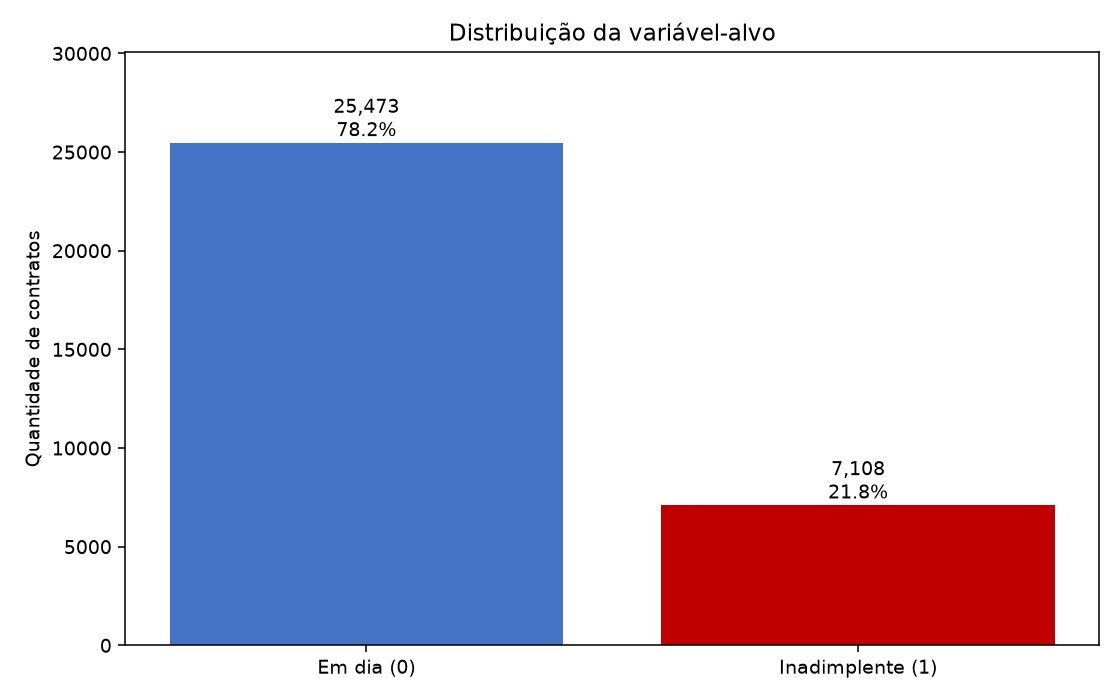

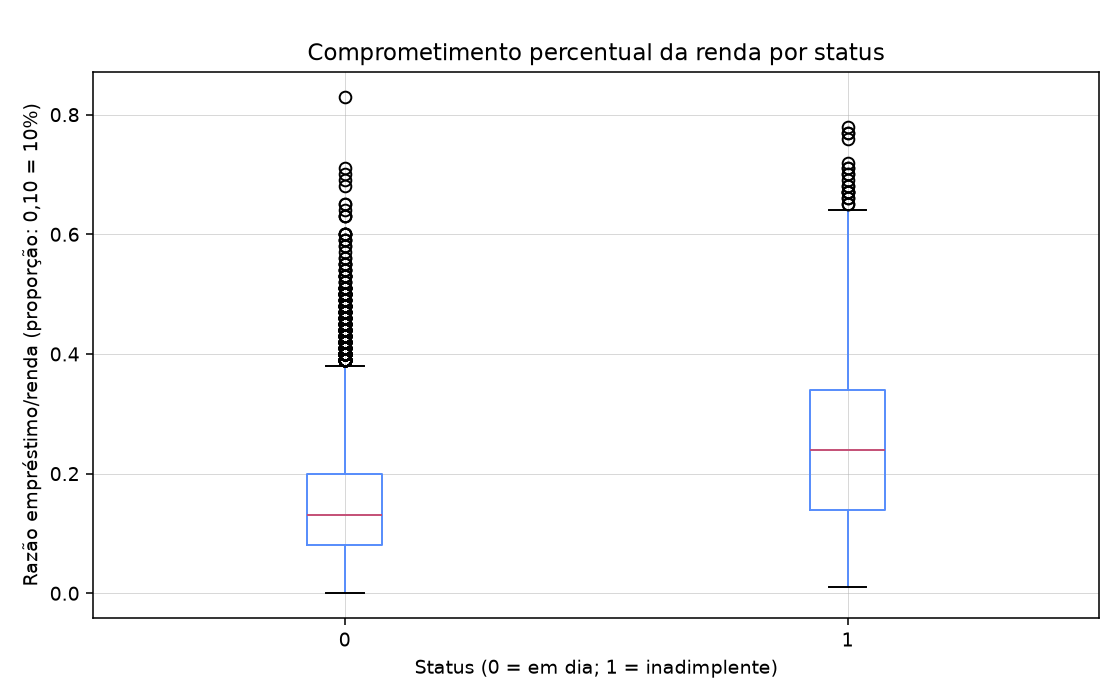

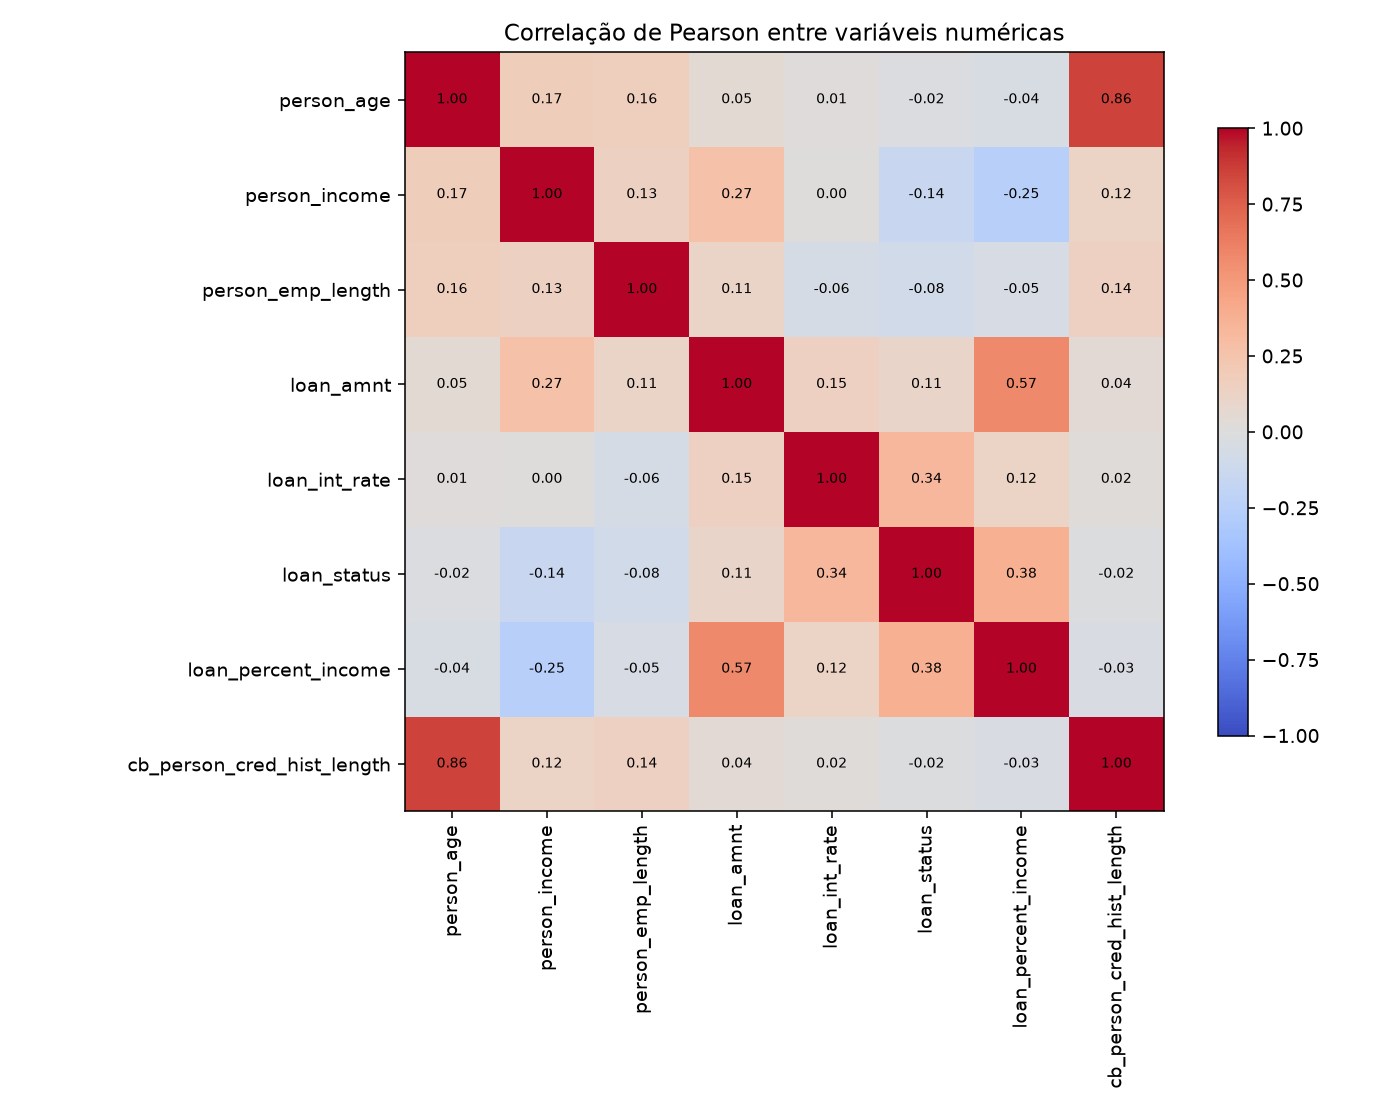

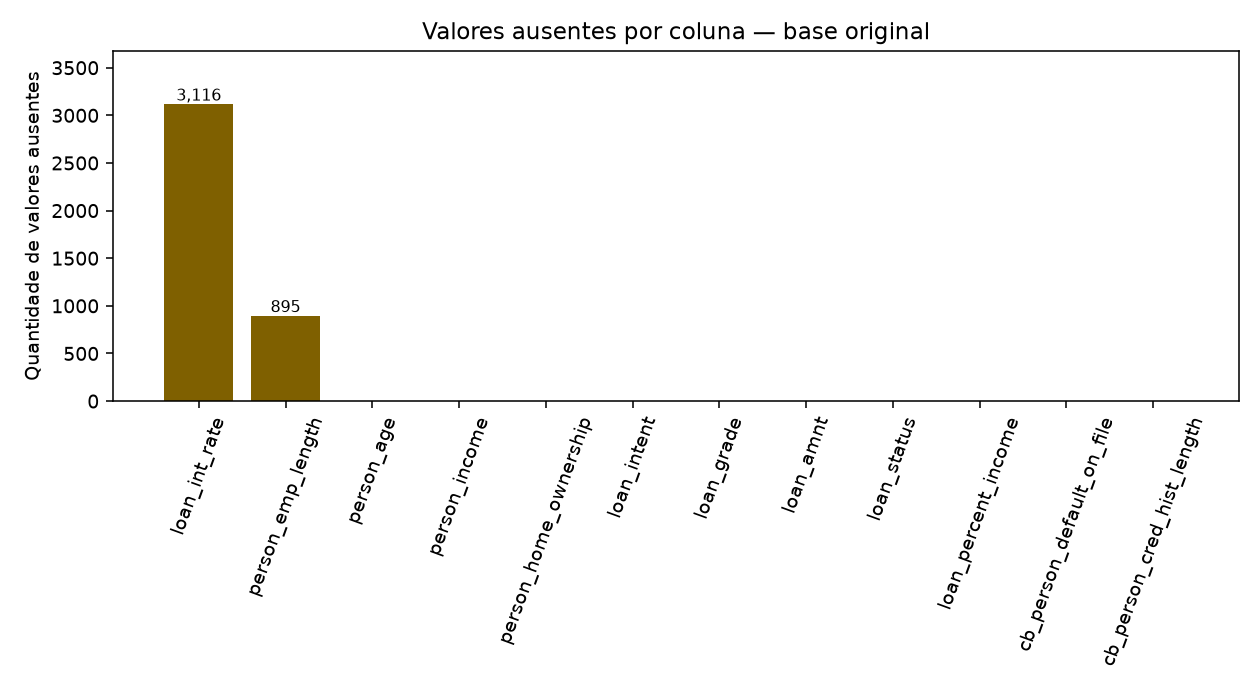

In [4]:
raw = pd.read_csv(ROOT / 'credit_risk_dataset.csv')
print('Dimensões originais:', raw.shape)
display(raw.describe())
for name in ['01_distribuicao_alvo', '03_boxplot_comprometimento', '04_correlacao_pearson', '05_valores_nulos']:
    display(Image(filename=str(ROOT / f'resultados/graficos_eda/{name}.png')))


## 2. Limpeza

Em `clean_data()`, `drop_duplicates()` retira 165 repetições exatas; cinco idades de 123 ou 144 anos saem da cópia de trabalho. Dois tempos de emprego de 123 anos, incompatíveis com a idade das pessoas, viram nulos. As rendas extremas ficam porque raridade, sozinha, não prova erro — essa decisão está detalhada, com o boxplot de outliers, na seção 2 de `documentacao/01_eda_e_preparacao.md` (já exibida acima). A base limpa tem 32.411 linhas. A imputação ainda não ocorre aqui: ela será ajustada no treino de cada dobra.


In [ ]:
display(pd.read_csv(ROOT / 'resultados/estatisticas_treino.csv'))


## 3. Variável calculada

`safe_ratio()` verifica se empréstimo e renda são finitos e positivos antes da divisão. `add_feature()` cria `comprometimento_renda = (loan_amnt / person_income) × 100`. A unidade é percentual do valor total do empréstimo em relação à renda anual; não é parcela mensal. A coluna original `loan_percent_income` sai dos preditores porque traz praticamente a mesma razão em outra escala. Detalhes na seção 3 de `documentacao/01_eda_e_preparacao.md`, já exibida acima.


In [ ]:
# Seção 3 já exibida na célula acima (documentacao/01_eda_e_preparacao.md).


## 4. Separação e preparação sem vazamento

`split_data()` separa 80% para treino e 20% para teste, preservando a proporção do alvo (`stratify=y`, semente 42). Em `prepare()`, imputação e codificação aprendem apenas com o treino recebido. Depois, o oversampling repete apenas exemplos da classe minoritária desse treino. O `StandardScaler` é ajustado nas cinco variáveis contínuas do KNN; a árvore recebe a matriz sem escala. A validação e o teste só recebem `transform`. Detalhes na seção 4 de `documentacao/01_eda_e_preparacao.md`, já exibida acima.


In [ ]:
# Seção 4 já exibida na célula acima (documentacao/01_eda_e_preparacao.md).


### Trecho do código: preparação

A célula abaixo exibe a função `prepare()` diretamente do arquivo usado na execução. Observe a ordem: `fit_transform` no treino, `transform` na avaliação, balanceamento só no treino e escala só no KNN. É a mesma função que produziu as métricas.

In [8]:
from inspect import getsource
from pipeline_credito import prepare
print(getsource(prepare))

def prepare(Xtrain, ytrain, Xeval):
    # Taxa de juros é quase simétrica: média; emprego tem cauda direita: mediana.
    numeric = Xtrain.select_dtypes(include="number").columns.tolist()
    median_cols = [c for c in numeric if c != "loan_int_rate"]
    categorical = Xtrain.select_dtypes(exclude="number").columns.tolist()
    transformer = ColumnTransformer([
        ("mediana", SimpleImputer(strategy="median"), median_cols),
        ("juros", SimpleImputer(strategy="mean"), ["loan_int_rate"]),
        ("categoria", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
    ])
    original = transformer.fit_transform(Xtrain)
    evaluation = transformer.transform(Xeval)
    names = transformer.get_feature_names_out().tolist()
    balanced_indices = oversample_indices(ytrain)
    balanced = original[balanced_indices].copy()
    balanced_y = ytrain.to_numpy()[balanced_indices]
    scale_indices = [
        i for i, name in enumerate(names) if name.split("__", 1)[1] i

## 5. KNN, árvore e sobreajuste

`run_cv()` compara K=3, 5, 7 e 9 no KNN e profundidades 3, 5, 7 e ilimitada na árvore, em cinco dobras estratificadas. Em cada dobra, `prepare()` reaprende as transformações usando somente o treino daquela dobra. Compare F1 de treino e validação nas curvas: a árvore ilimitada chega a F1=1,0000 no treino, mas cai na validação. `select_configs()` escolhe o maior F1 médio de validação da classe 1; os vencedores foram K=9 e profundidade 7. As curvas também mostram o teste para análise posterior, não para escolher os parâmetros.


In [ ]:
display(Markdown((ROOT / 'documentacao/02_modelagem.md').read_text()))
display(pd.read_csv(ROOT / 'resultados/experimentos_corrigidos.csv'))
display(Image(filename=str(ROOT / 'resultados/avaliacao_final/curva_validacao_knn.png')))
display(Image(filename=str(ROOT / 'resultados/avaliacao_final/curva_overfitting_arvore.png')))


## 6. Avaliação e decisão de negócio

`model_artifacts()` gera o relatório de classificação e a matriz de confusão dos dois finalistas. Na matriz, falso positivo é um bom pagador marcado como risco; falso negativo é um inadimplente não detectado. A simulação de custos usa R$ 1.000 por FP e R$ 5.000 por FN apenas para comparar cenários. Nesse cenário, a árvore tem custo menor, mas isso não equivale a economia observada pelo banco.


In [ ]:
display(Markdown((ROOT / 'documentacao/03_avaliacao_e_veredito.md').read_text()))
display(pd.read_csv(ROOT / 'resultados/avaliacao_corrigida.csv'))
display(Image(filename=str(ROOT / 'resultados/avaliacao_final/feature_importance_arvore.png')))


                  precision    recall  f1-score   support

      Em dia (0)     0.9174    0.7980    0.8536      5065
Inadimplente (1)     0.5075    0.7433    0.6031      1418

        accuracy                         0.7861      6483
       macro avg     0.7124    0.7707    0.7284      6483
    weighted avg     0.8277    0.7861    0.7988      6483



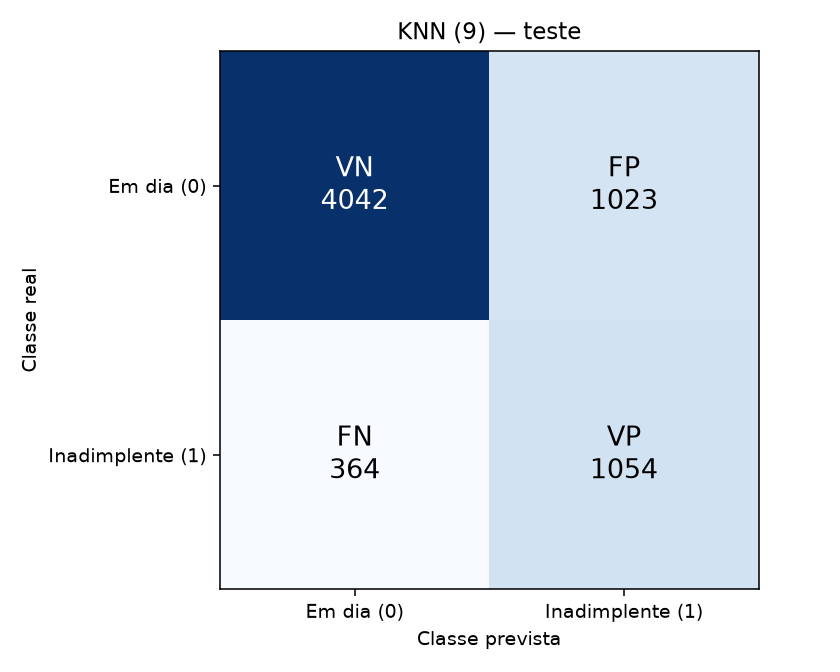

                  precision    recall  f1-score   support

      Em dia (0)     0.9270    0.9504    0.9386      5065
Inadimplente (1)     0.8054    0.7327    0.7674      1418

        accuracy                         0.9028      6483
       macro avg     0.8662    0.8416    0.8530      6483
    weighted avg     0.9004    0.9028    0.9011      6483



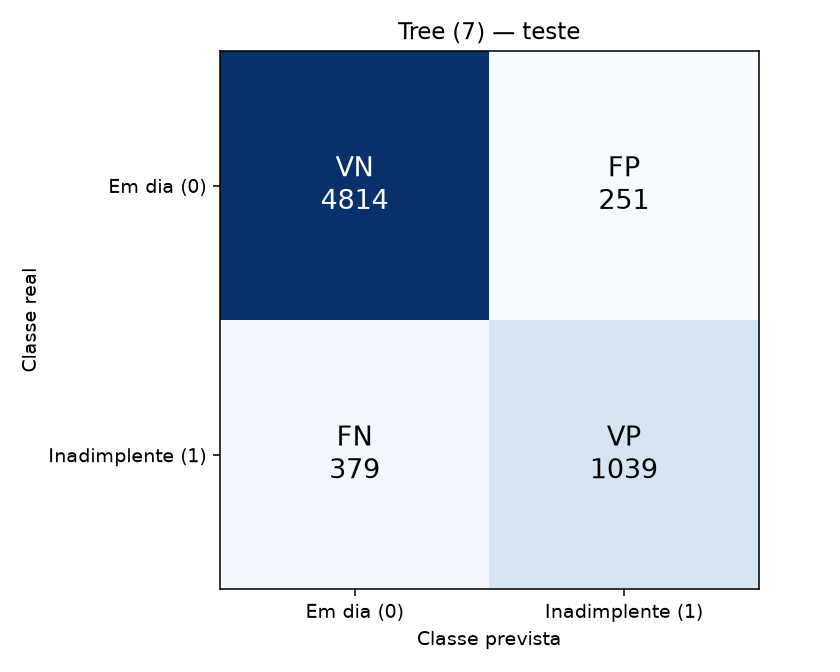

In [11]:
import json
selected = json.loads((ROOT / 'resultados/parametros_selecionados.json').read_text())['selecionados']
for model, param in selected.items():
    prefix = f'knn_k{param}' if model == 'KNN' else f'arvore_depth{param}'
    folder = ROOT / 'resultados/avaliacao_final'
    print((folder / f'{prefix}_classification_report.txt').read_text())
    display(Image(filename=str(folder / f'{prefix}_matriz_confusao.png')))


## Verificação complementar (opcional)

`04_analise_complementar.py` não é exigido pelo problema e não é chamado automaticamente por `03_executar_pipeline.py`. Compara uma referência aleatória estratificada com a árvore completa e uma árvore sem `loan_grade`/`loan_int_rate`, usando só as dobras de treino. Se você já rodou esse script manualmente, o resultado está na seção "Verificação complementar" de `documentacao/03_avaliacao_e_veredito.md` (já exibida acima); a célula abaixo só confirma se essa seção existe.


In [ ]:
texto = (ROOT / 'documentacao/03_avaliacao_e_veredito.md').read_text()
if 'Para gerá-la, rode' in texto:
    print('Ainda não rodado: execute notebooks/04_analise_complementar.py para gerar esta seção.')
else:
    print('Já rodado — resultado incluído na exibição de documentacao/03_avaliacao_e_veredito.md acima.')


## Limites e integridade

O teste já tinha sido consultado durante o desenvolvimento anterior. A seleção desta versão usa só a validação interna, mas não recupera um conjunto externo intocado. A base também não informa quando juros e classificação de risco estão disponíveis. Uma aplicação real exigiria confirmar esses pontos e validar o modelo em novos dados. A última célula confere novamente os hashes dos CSVs originais.


In [12]:
from pipeline_credito import verify_originals
verify_originals()
print('Integridade dos CSVs originais confirmada.')


Integridade dos CSVs originais confirmada.
